In [2]:
import gizmo_analysis as gizmo
import utilities as ut
import numpy as np
import matplotlib.pyplot as plt


# in utilities.simulation.Snapshot():
* reading:  home/eriley1/bighome/warp-data/m12b/snapshot_times.txt

  using snapshot index = 385, redshift = 0.488


# in gizmo_analysis.gizmo_io.Read():
* reading header from:  home/eriley1/bighome/warp-data/m12b/output/snapdir_385/snapshot_385.0.hdf5
  snapshot contains the following number of particles:
    dark      (id = 1): 74537000 particles
    dark2     (id = 2): 6750970 particles
    gas       (id = 0): 64162001 particles
    star      (id = 4): 10869964 particles
    blackhole (id = 5): 0 particles

* reading the following
  species: ['star']

* reading particles from:
    snapshot_385.0.hdf5
    snapshot_385.1.hdf5
    snapshot_385.2.hdf5
    snapshot_385.3.hdf5
    snapshot_385.4.hdf5
    snapshot_385.5.hdf5
    snapshot_385.6.hdf5
    snapshot_385.7.hdf5

! cannot find MUSIC config file:  home/eriley1/bighome/warp-data/m12b/*/*.conf
! missing cosmological parameters, assuming cosmology from AGORA
  assuming omega_baryon = 0.0455
  as

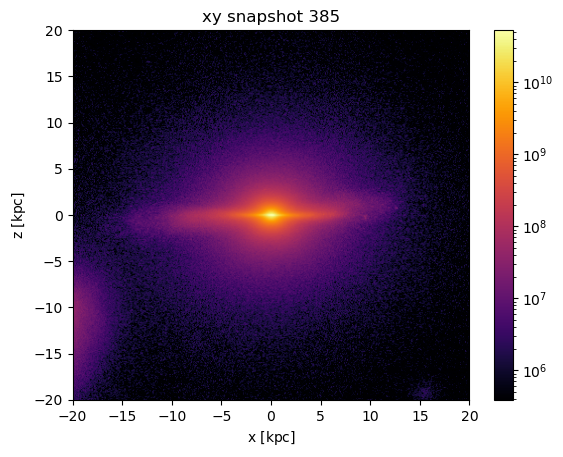

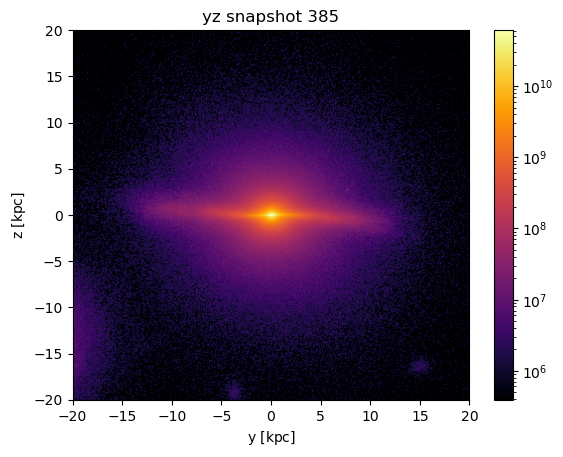

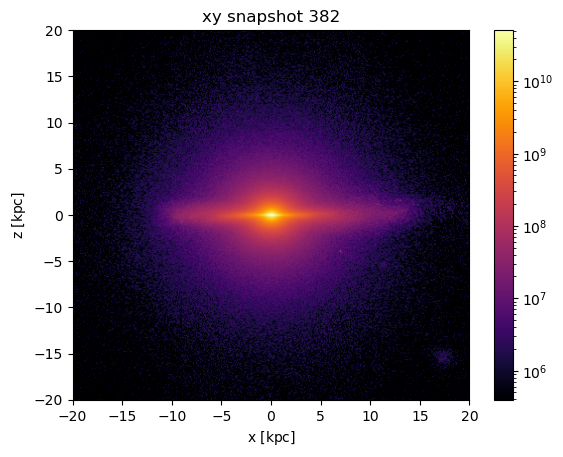

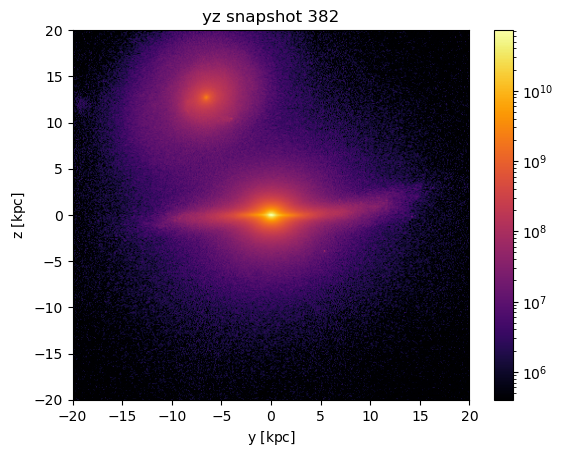

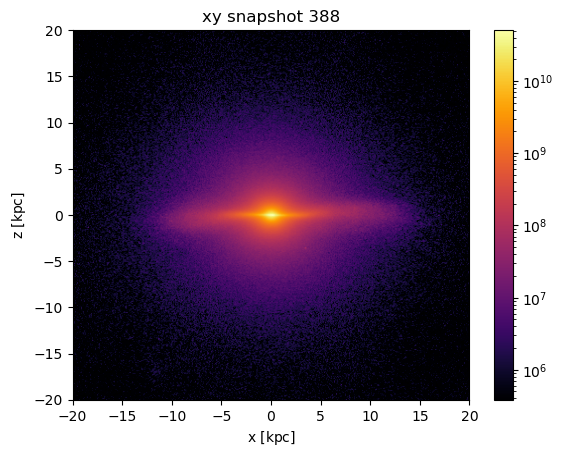

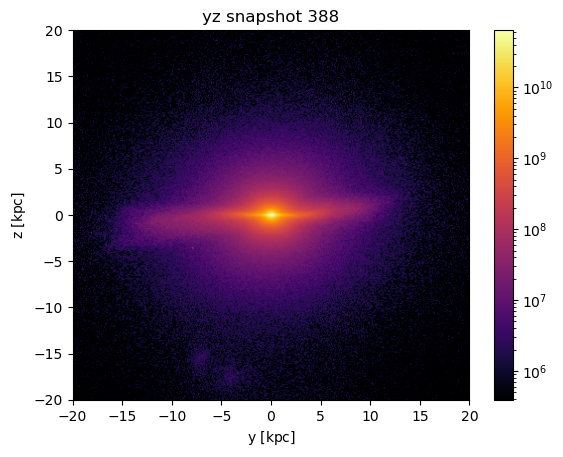

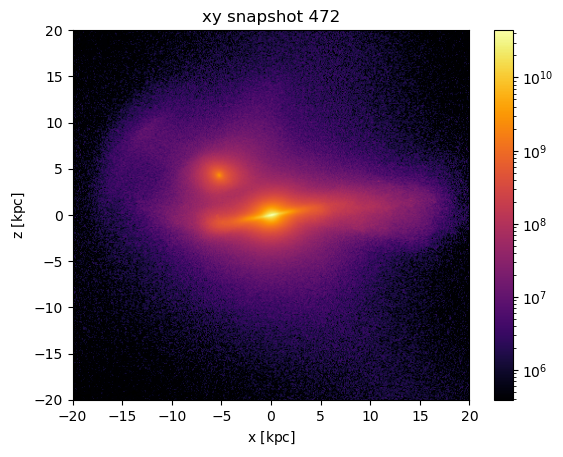

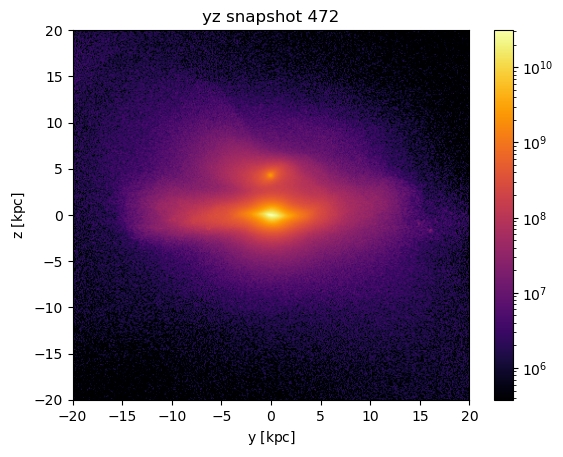

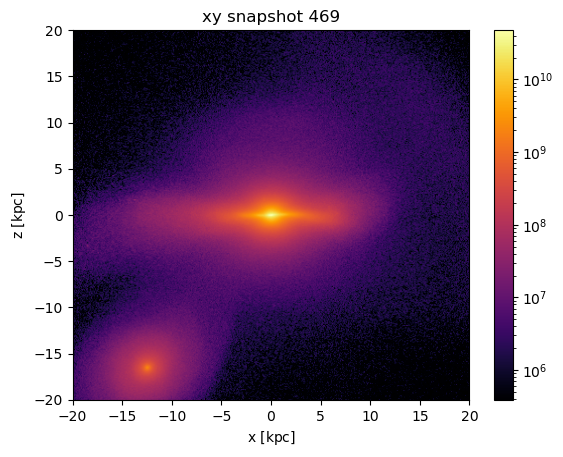

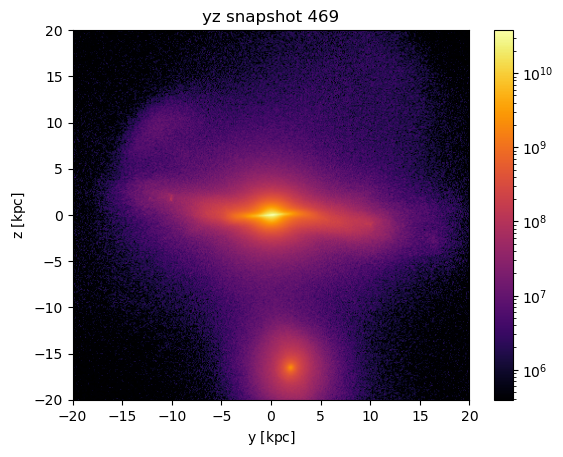

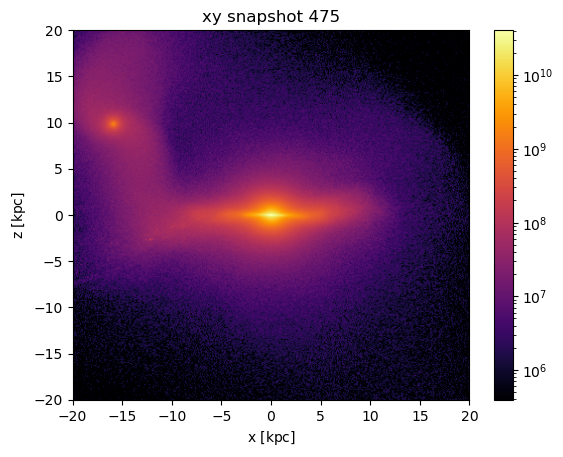

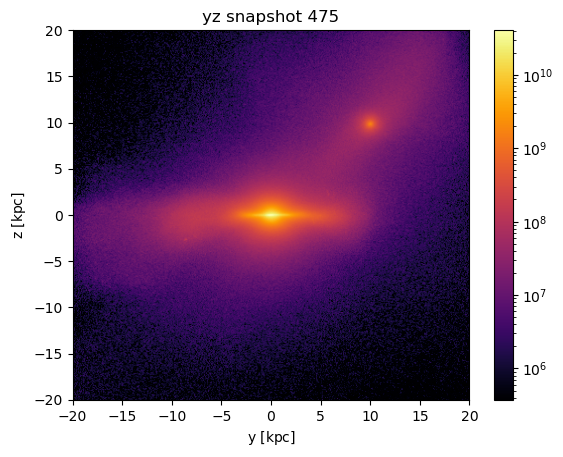

In [13]:
simulation_directory = '/home/eriley1/bighome/warp-data/m12b'

for i in [385,382,388,472,469,475]:
    part = gizmo.io.Read.read_snapshots('star', 'index', i, simulation_directory, assign_hosts_rotation=True,
                                            assign_hosts=True)

    SpeciesProfile = ut.particle.SpeciesProfileClass(

    limits=[0, 20], width=1, log_scale=False, dimension_number=3)

    pro = SpeciesProfile.get_sum_profiles(part, 'star', 'mass')

    def plot_image_xz(
        part,
        species_name='star',
        weight_name='mass',
        part_indices=None,
        dimensions_plot=[0, 2],
        distance_max=20,
        distance_bin_width=0.1,
        rotation=True,
        host_index=0,
        image_limits=[None, None],
    ):

        from matplotlib import colors

        dimen_label = {0: 'x', 1: 'y', 2: 'z'}

        # get distance limits for plot
        position_limits = [[-distance_max, distance_max] for _ in range(2)]
        position_limits = np.array(position_limits)

        # get array of particle indices (if not input)
        if part_indices is None or len(part_indices) == 0:
            part_indices = ut.array.get_arange(part[species_name]['position'].shape[0])

        # get positions relative to host galaxy center
        host_name = ut.catalog.get_host_name(host_index)
        if rotation is True:
            # rotate according to principal axes
            positions = part[species_name].prop(f'{host_name}.distance.principal', part_indices)
        else:
            # positions in (arbitrary) Cartesian x,y,z of simulation
            positions = part[species_name].prop(f'{host_name}.distance', part_indices)

        # weight particles by some property?
        weights = None
        if weight_name:
            weights = part[species_name].prop(weight_name, part_indices)

        # keep only particles within distance limits along each dimension
        masks = positions[:, dimensions_plot[0]] <= distance_max
        for dimen_i in dimensions_plot:
            masks *= (positions[:, dimen_i] >= -distance_max) * (positions[:, dimen_i] <= distance_max)

        # keep only positions and weights within distance limits
        positions = positions[masks]
        if weights is not None:
            weights = weights[masks]

        # get number of bins (pixels) along each dimension
        position_bin_number = int(np.round(2 * np.max(distance_max) / distance_bin_width))

        # get 2-D histogram
        hist_valuess, hist_xs, hist_ys = np.histogram2d(
            positions[:, dimensions_plot[0]],
            positions[:, dimensions_plot[1]],
            position_bin_number,
            position_limits,
            weights=weights,
        )
        # convert to surface density
        hist_valuess /= np.diff(hist_xs)[0] * np.diff(hist_ys)[0]

        # set color map
        if 'dark' in species_name:
            color_map = plt.cm.afmhot
        elif species_name == 'gas':
            color_map = plt.cm.afmhot
        elif species_name == 'star':
            color_map = plt.cm.inferno

        fig = plt.figure()
        subplot = fig.add_subplot(111, facecolor='black')

        subplot.set_xlim(position_limits[0])
        subplot.set_ylim(position_limits[1])

        subplot.set_xlabel(f'{dimen_label[dimensions_plot[0]]} $\\left[ {{\\rm kpc}} \\right]$')
        subplot.set_ylabel(f'{dimen_label[dimensions_plot[1]]} $\\left[ {{\\rm kpc}} \\right]$')
        subplot.set_title(f"xy snapshot {i}")

        # make 2-D histogram image
        Image = subplot.imshow(
            hist_valuess.transpose(),
            norm=colors.LogNorm(),
            cmap=color_map,
            aspect='auto',
            interpolation='bilinear',
            extent=np.concatenate(position_limits),
            vmin=image_limits[0],
            vmax=image_limits[1],
        )

        fig.colorbar(Image)
        
        plt.savefig('imag.png')

    plot_image_xz(part)

    def plot_image_yz(
        part,
        species_name='star',
        weight_name='mass',
        part_indices=None,
        dimensions_plot=[1, 2],
        distance_max=20,
        distance_bin_width=0.1,
        rotation=True,
        host_index=0,
        image_limits=[None, None],
    ):

        from matplotlib import colors

        dimen_label = {0: 'x', 1: 'y', 2: 'z'}

        # get distance limits for plot
        position_limits = [[-distance_max, distance_max] for _ in range(2)]
        position_limits = np.array(position_limits)

        # get array of particle indices (if not input)
        if part_indices is None or len(part_indices) == 0:
            part_indices = ut.array.get_arange(part[species_name]['position'].shape[0])

        # get positions relative to host galaxy center
        host_name = ut.catalog.get_host_name(host_index)
        if rotation is True:
            # rotate according to principal axes
            positions = part[species_name].prop(f'{host_name}.distance.principal', part_indices)
        else:
            # positions in (arbitrary) Cartesian x,y,z of simulation
            positions = part[species_name].prop(f'{host_name}.distance', part_indices)

        # weight particles by some property?
        weights = None
        if weight_name:
            weights = part[species_name].prop(weight_name, part_indices)

        # keep only particles within distance limits along each dimension
        masks = positions[:, dimensions_plot[0]] <= distance_max
        for dimen_i in dimensions_plot:
            masks *= (positions[:, dimen_i] >= -distance_max) * (positions[:, dimen_i] <= distance_max)

        # keep only positions and weights within distance limits
        positions = positions[masks]
        if weights is not None:
            weights = weights[masks]

        # get number of bins (pixels) along each dimension
        position_bin_number = int(np.round(2 * np.max(distance_max) / distance_bin_width))

        # get 2-D histogram
        hist_valuess, hist_xs, hist_ys = np.histogram2d(
            positions[:, dimensions_plot[0]],
            positions[:, dimensions_plot[1]],
            position_bin_number,
            position_limits,
            weights=weights,
        )
        # convert to surface density
        hist_valuess /= np.diff(hist_xs)[0] * np.diff(hist_ys)[0]

        # set color map
        if 'dark' in species_name:
            color_map = plt.cm.afmhot
        elif species_name == 'gas':
            color_map = plt.cm.afmhot
        elif species_name == 'star':
            color_map = plt.cm.inferno

        fig = plt.figure()
        subplot = fig.add_subplot(111, facecolor='black')

        subplot.set_xlim(position_limits[0])
        subplot.set_ylim(position_limits[1])

        subplot.set_xlabel(f'{dimen_label[dimensions_plot[0]]} $\\left[ {{\\rm kpc}} \\right]$')
        subplot.set_ylabel(f'{dimen_label[dimensions_plot[1]]} $\\left[ {{\\rm kpc}} \\right]$')
        subplot.set_title(f"yz snapshot {i}")

        # make 2-D histogram image
        Image = subplot.imshow(
            hist_valuess.transpose(),
            norm=colors.LogNorm(),
            cmap=color_map,
            aspect='auto',
            interpolation='bilinear',
            extent=np.concatenate(position_limits),
            vmin=image_limits[0],
            vmax=image_limits[1],
        )

        fig.colorbar(Image)
        
        plt.savefig('imag.png')

    plot_image_yz(part)